# Лабораторная работа №5
## Прогнозирование оттока клиентов банка (Bank Customer Churn Prediction)

**Цель:** спрогнозировать отток клиентов из банка (целевая переменная `churn`) с максимальным показателем **F1 для класса `churn=1`**.


In [7]:
!pip install -q imbalanced-learn xgboost

---
## 1. Импорт библиотек

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             f1_score, precision_recall_curve,
                             ConfusionMatrixDisplay)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 6)
print('Библиотеки успешно загружены')

Библиотеки успешно загружены


---
## 2. Загрузка данных

Загружаем файл `Bank Customer Churn Prediction.csv`. В Google Colab удобно загружать через `files.upload()` или из Google Drive.

In [9]:
# --- Вариант C: файл в текущей директории (например, после files.upload) ---
path = 'Bank Customer Churn Prediction.csv'

df = pd.read_csv(path)
print('Размер набора данных:', df.shape)
df.head()

Размер набора данных: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# Общая информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [11]:
# Статистика по числовым признакам
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Распределение классов (churn):
churn
0    7963
1    2037
Name: count, dtype: int64

Доля положительного класса: 0.204


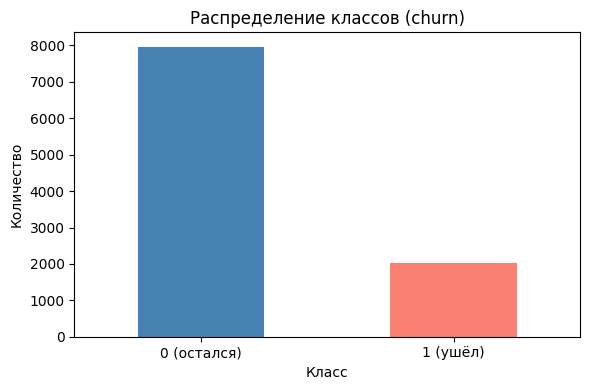

In [12]:
# Распределение целевого класса
print('Распределение классов (churn):')
print(df['churn'].value_counts())
print(f'Доля положительного класса: {df["churn"].mean():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
df['churn'].value_counts().plot.bar(color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Распределение классов (churn)')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
ax.set_xticklabels(['0 (остался)', '1 (ушёл)'], rotation=0)
plt.tight_layout()
plt.show()

**Промежуточные выводы.** Классы существенно несбалансированы. Это означает:
- метрика Accuracy будет вводить в заблуждение;
- потребуется устранение дисбаланса (SMOTE, class_weight='balanced', scale_pos_weight);
- стандартный порог классификации 0.5 — не оптимален; будем подбирать его по максимуму F1.

---
## 3. Препроцессинг данных

In [13]:
# Пропущенные значения
print('Пропущенные значения по столбцам:')
print(df.isnull().sum())

Пропущенные значения по столбцам:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [14]:
# customer_id — идентификатор, не является признаком, удаляем
df = df.drop(columns=['customer_id'])

# Категориальные признаки: country, gender — применим one-hot кодирование
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

print('Колонки после кодирования:')
print(df.columns.tolist())
df.head()

Колонки после кодирования:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'country_Germany', 'country_Spain', 'gender_Male']


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [15]:
# --- Конструирование новых признаков (feature engineering) ---
# 1) отношение баланса к зарплате — сигнал о сбережениях
df['balance_salary_ratio'] = df['balance'] / (df['estimated_salary'] + 1)
# 2) отношение стажа к возрасту — лояльность относительно возраста
df['tenure_age_ratio'] = df['tenure'] / (df['age'] + 1)
# 3) кредитный рейтинг на год возраста
df['credit_score_age'] = df['credit_score'] / (df['age'] + 1)
# 4) бинарный индикатор нулевого баланса — таких клиентов в датасете много
df['zero_balance'] = (df['balance'] == 0).astype(int)

print('Форма после feature engineering:', df.shape)
df.head()

Форма после feature engineering: (10000, 16)


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male,balance_salary_ratio,tenure_age_ratio,credit_score_age,zero_balance
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,0.046512,14.395349,1
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,0.023810,14.476190,0
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,0.186047,11.674419,0
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,0.025000,17.475000,1
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,0.045455,19.318182,0


In [16]:
# Корреляция числовых признаков с churn (быстрый сайд-чек)
corr = df.corr(numeric_only=True)['churn'].drop('churn').sort_values(key=abs, ascending=False)
print('Корреляция признаков с churn (по модулю):')
print(corr)

Корреляция признаков с churn (по модулю):
age                     0.285323
credit_score_age       -0.253008
country_Germany         0.173488
active_member          -0.156128
zero_balance           -0.122357
tenure_age_ratio       -0.119651
balance                 0.118533
gender_Male            -0.106512
country_Spain          -0.052667
products_number        -0.047820
credit_score           -0.027094
balance_salary_ratio    0.025963
tenure                 -0.014001
estimated_salary        0.012097
credit_card            -0.007138
Name: churn, dtype: float64


### Разбиение на обучающий и тестовый наборы (75% / 25%)


In [17]:
y = df['churn']
X = df.drop(columns=['churn'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Доля churn=1 в train: {y_train.mean():.3f}')
print(f'Доля churn=1 в test : {y_test.mean():.3f}')

Train: (7500, 15),  Test: (2500, 15)
Доля churn=1 в train: 0.204
Доля churn=1 в test : 0.204


### Нормализация признаков


In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Для удобства — сохраним имена признаков
feature_names = X_train.columns.tolist()
print('Нормализация выполнена. Признаков:', len(feature_names))

Нормализация выполнена. Признаков: 15


### Устранение дисбаланса классов — SMOTE


In [19]:
print('До SMOTE:', pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print('После SMOTE:', pd.Series(y_train_bal).value_counts().to_dict())

До SMOTE: {0: 5972, 1: 1528}
После SMOTE: {0: 5972, 1: 5972}


---
## 4. Вспомогательные функции

- find_best_threshold — подбор оптимального порога классификации по F1;
- evaluate — выводит метрики и возвращает словарь результатов;
- plot_confusion — красивая визуализация матрицы ошибок.

In [20]:
def find_best_threshold(y_true, y_proba):
    """Подбираем порог, максимизирующий F1 для положительного класса."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.nanargmax(f1_scores[:-1]) if len(thresholds) > 0 else 0
    return thresholds[best_idx], f1_scores[best_idx]


def evaluate(model_name, y_true, y_proba):
    """Вычисляет метрики и печатает отчёт. Возвращает словарь результатов."""
    # Оптимальный порог по F1
    best_thr, best_f1 = find_best_threshold(y_true, y_proba)
    y_pred = (y_proba >= best_thr).astype(int)

    auc = roc_auc_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)

    print(f' {model_name} ')
    print(f'Оптимальный порог по F1: {best_thr:.3f}')
    print(f'F1 (class=1) = {f1:.4f}   |   ROC-AUC = {auc:.4f}')
    print('Матрица ошибок:')
    print(confusion_matrix(y_true, y_pred))
    print('Classification report:')
    print(classification_report(y_true, y_pred, digits=4))

    return {
        'name':  model_name,
        'proba': y_proba,
        'pred':  y_pred,
        'f1':    f1,
        'auc':   auc,
        'thr':   best_thr,
    }


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=['0 (остался)', '1 (ушёл)']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


results = {}  # сюда будем складывать результаты всех моделей

---
## 5. Модель 1 — Дерево решений (Decision Tree)

Используем class_weight='balanced' и ограничение глубины, чтобы избежать переобучения.

In [37]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    criterion='gini',
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
dt_model.fit(X_train_sc, y_train)

proba_dt = dt_model.predict_proba(X_test_sc)[:, 1]
results['Decision Tree'] = evaluate('Decision Tree', y_test, proba_dt)


=== Decision Tree ===
Оптимальный порог по F1: 0.651
F1 (class=1) = 0.5691   |   ROC-AUC = 0.8287

Матрица ошибок:
[[1796  195]
 [ 229  280]]

Classification report:
              precision    recall  f1-score   support

           0     0.8869    0.9021    0.8944      1991
           1     0.5895    0.5501    0.5691       509

    accuracy                         0.8304      2500
   macro avg     0.7382    0.7261    0.7318      2500
weighted avg     0.8264    0.8304    0.8282      2500



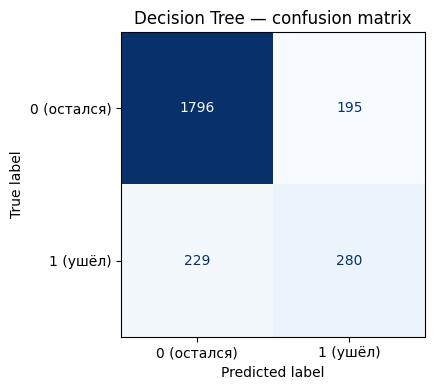

In [22]:
plot_confusion(y_test, results['Decision Tree']['pred'], 'Decision Tree — confusion matrix')

---
## 6. Модель 2 — Случайный лес (Random Forest)

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train_sc, y_train)

proba_rf = rf_model.predict_proba(X_test_sc)[:, 1]
results['Random Forest'] = evaluate('Random Forest', y_test, proba_rf)


=== Random Forest ===
Оптимальный порог по F1: 0.481
F1 (class=1) = 0.6101   |   ROC-AUC = 0.8520

Матрица ошибок:
[[1746  245]
 [ 178  331]]

Classification report:
              precision    recall  f1-score   support

           0     0.9075    0.8769    0.8920      1991
           1     0.5747    0.6503    0.6101       509

    accuracy                         0.8308      2500
   macro avg     0.7411    0.7636    0.7510      2500
weighted avg     0.8397    0.8308    0.8346      2500



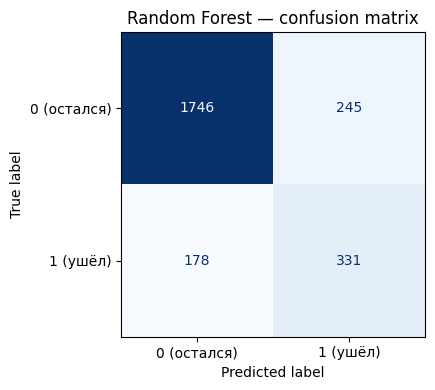

In [24]:
plot_confusion(y_test, results['Random Forest']['pred'], 'Random Forest — confusion matrix')

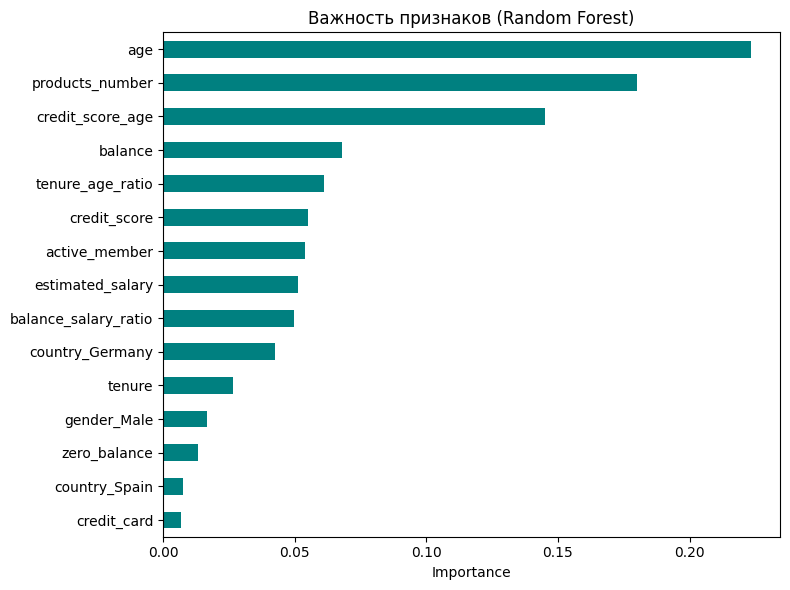

In [25]:
# Важность признаков по Random Forest
imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color='teal')
ax.set_title('Важность признаков (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## 7. Модель 3 — Градиентный бустинг (Gradient Boosting)

In [26]:
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train_sc, y_train)

proba_gb = gb_model.predict_proba(X_test_sc)[:, 1]
results['Gradient Boosting'] = evaluate('Gradient Boosting', y_test, proba_gb)


=== Gradient Boosting ===
Оптимальный порог по F1: 0.375
F1 (class=1) = 0.6089   |   ROC-AUC = 0.8594

Матрица ошибок:
[[1858  133]
 [ 228  281]]

Classification report:
              precision    recall  f1-score   support

           0     0.8907    0.9332    0.9115      1991
           1     0.6787    0.5521    0.6089       509

    accuracy                         0.8556      2500
   macro avg     0.7847    0.7426    0.7602      2500
weighted avg     0.8475    0.8556    0.8499      2500



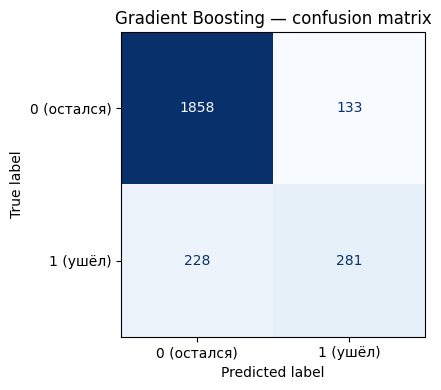

In [27]:
plot_confusion(y_test, results['Gradient Boosting']['pred'], 'Gradient Boosting — confusion matrix')

---
## 8. Модель 4 — AdaBoost

In [28]:
ada_model = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
)
ada_model.fit(X_train_sc, y_train)

proba_ada = ada_model.predict_proba(X_test_sc)[:, 1]
results['AdaBoost'] = evaluate('AdaBoost', y_test, proba_ada)


=== AdaBoost ===
Оптимальный порог по F1: 0.430
F1 (class=1) = 0.6021   |   ROC-AUC = 0.8459

Матрица ошибок:
[[1713  278]
 [ 170  339]]

Classification report:
              precision    recall  f1-score   support

           0     0.9097    0.8604    0.8844      1991
           1     0.5494    0.6660    0.6021       509

    accuracy                         0.8208      2500
   macro avg     0.7296    0.7632    0.7432      2500
weighted avg     0.8364    0.8208    0.8269      2500



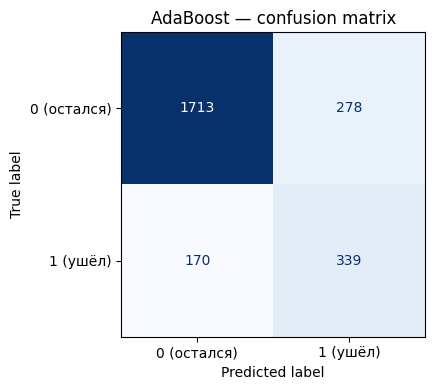

In [29]:
plot_confusion(y_test, results['AdaBoost']['pred'], 'AdaBoost — confusion matrix')

---
## 9. Модель 5 — XGBoost

Один из самых мощных ансамблевых методов. Используем `scale_pos_weight` — встроенный способ учесть дисбаланс классов в XGBoost.

In [30]:
# Соотношение классов: neg / pos — именно этот параметр рекомендует документация XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight =', round(scale_pos_weight, 3))

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train_sc, y_train)

proba_xgb = xgb_model.predict_proba(X_test_sc)[:, 1]
results['XGBoost'] = evaluate('XGBoost', y_test, proba_xgb)

scale_pos_weight = 3.908

=== XGBoost ===
Оптимальный порог по F1: 0.485
F1 (class=1) = 0.6123   |   ROC-AUC = 0.8524

Матрица ошибок:
[[1734  257]
 [ 171  338]]

Classification report:
              precision    recall  f1-score   support

           0     0.9102    0.8709    0.8901      1991
           1     0.5681    0.6640    0.6123       509

    accuracy                         0.8288      2500
   macro avg     0.7392    0.7675    0.7512      2500
weighted avg     0.8406    0.8288    0.8336      2500



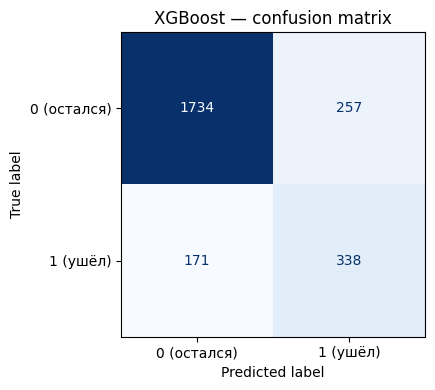

In [31]:
plot_confusion(y_test, results['XGBoost']['pred'], 'XGBoost — confusion matrix')

---
## 10. Модель 6 — Нейронная сеть (MLP)

Обучаем на сбалансированных через SMOTE данных. Архитектура: 2 скрытых слоя 64 → 32, ReLU, early stopping.

In [32]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-3,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_train_bal, y_train_bal)

proba_mlp = mlp_model.predict_proba(X_test_sc)[:, 1]
results['MLP (Neural Net)'] = evaluate('MLP (Neural Net)', y_test, proba_mlp)


=== MLP (Neural Net) ===
Оптимальный порог по F1: 0.689
F1 (class=1) = 0.5771   |   ROC-AUC = 0.8141

Матрица ошибок:
[[1785  206]
 [ 219  290]]

Classification report:
              precision    recall  f1-score   support

           0     0.8907    0.8965    0.8936      1991
           1     0.5847    0.5697    0.5771       509

    accuracy                         0.8300      2500
   macro avg     0.7377    0.7331    0.7354      2500
weighted avg     0.8284    0.8300    0.8292      2500



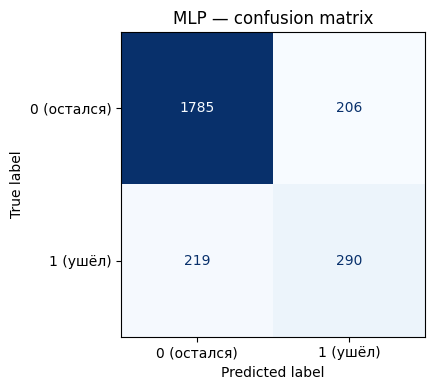

In [33]:
plot_confusion(y_test, results['MLP (Neural Net)']['pred'], 'MLP — confusion matrix')

---
## 11. Сравнение моделей — ROC-кривые на одном графике

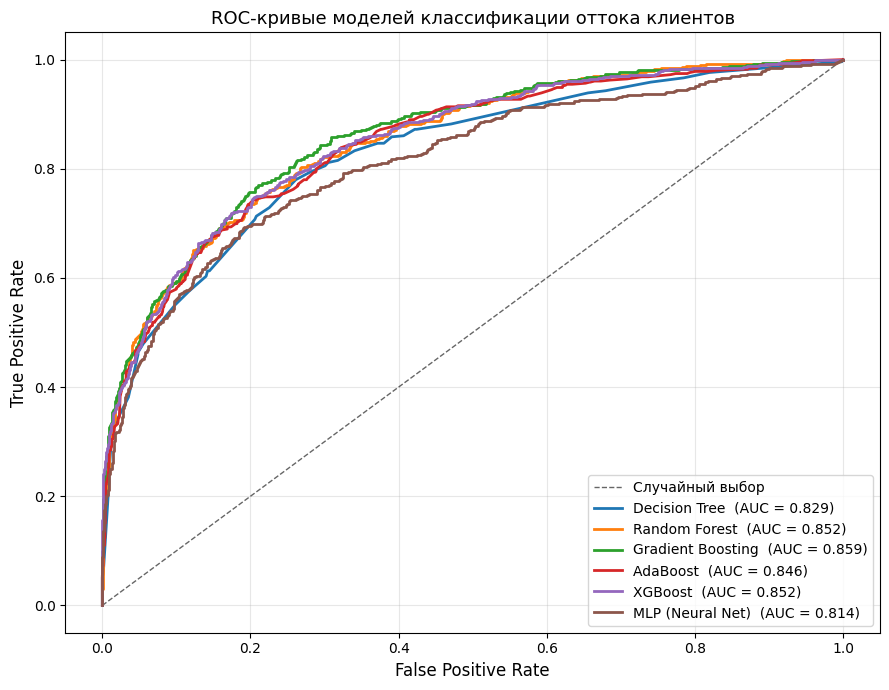

In [34]:
plt.figure(figsize=(9, 7))

# Диагональ — уровень случайного классификатора
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Случайный выбор')

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, lw=2, label=f"{name}  (AUC = {res['auc']:.3f})")

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые моделей классификации оттока клиентов', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Итоговая сводная таблица

In [35]:
summary = pd.DataFrame([
    {'Модель': r['name'],
     'F1 (churn=1)': round(r['f1'], 4),
     'ROC-AUC': round(r['auc'], 4),
     'Порог': round(r['thr'], 3)}
    for r in results.values()
]).sort_values('F1 (churn=1)', ascending=False).reset_index(drop=True)

summary

,Модель,F1 (churn=1),ROC-AUC,Порог
0,XGBoost,0.6123,0.8524,0.485
1,Random Forest,0.6101,0.8520,0.481
2,Gradient Boosting,0.6089,0.8594,0.375
3,AdaBoost,0.6021,0.8459,0.430
4,MLP (Neural Net),0.5771,0.8141,0.689
5,Decision Tree,0.5691,0.8287,0.651


In [38]:
best = summary.iloc[0]
print(f"Лучшие показатели у: {best['Модель']}")
print(f"F1 (класс churn=1) = {best['F1 (churn=1)']:.4f}")


Лучшие показатели у: XGBoost
F1 (класс churn=1) = 0.6123
